# Supp. Fig. 21 — Combined Neighborhood-Enrichment Heatmaps (All Tissues)

**Purpose:** Combine the per-tissue hepatocyte-subset neighborhood-enrichment
tables produced by the KEGG ECM and Reactome fatty-acid pathway-scoring
notebooks (`kegg_ecm_receptor_interaction_neighbor.txt` /
`reactome_fatty_acids_neighbor.txt`, one file per tissue, each with rows for
"background" and "top-1%-score" hepatocytes) into a single combined heatmap
per pathway.

For each pathway, this produces four PDF heatmaps:
- Raw z-scores, unannotated / annotated with values
- `sign(x) * log10(|x| + 1e-6)`-transformed z-scores (compresses the scale
  so both strongly positive and negative enrichments are visible),
  unannotated / annotated

**Inputs:** per-tissue neighbor-enrichment tables written by the
`250828_01_..._kegg_ecm_...` and `250828_02_..._reactome_fatty_acids_...`
notebooks, found via `glob` under each pathway's output directory.

**Cleanup notes (this pass):** removed a stray line that was just a
filesystem path pasted directly into a code cell (not valid Python, would
raise a `SyntaxError`), a block of code copy-pasted from the per-sample
scoring notebook that referenced variables never defined here (`full_adata`,
`ct_sort`, `heps_labels`), duplicate re-imports of `glob`/`os`, and one
unsaved duplicate heatmap plot (the KEGG log-scale annotated heatmap was
plotted twice; only the copy that actually saves the PDF is kept).

In [11]:
import os
import glob

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


## KEGG ECM-receptor interaction — combined across tissues

In [3]:
outp = '/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/fnih_deg_pathways_module_score_mash/'


In [4]:
base_dir = outp

# Find the per-tissue neighbor-enrichment tables written by the KEGG scoring notebook
csv_files = glob.glob(os.path.join(base_dir, "*", "kegg*.txt"), recursive=True)
print(csv_files)


['/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/fnih_deg_pathways_module_score_mash/HL160029_filt/kegg_ecm_receptor_interaction_neighbor.txt', '/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/fnih_deg_pathways_module_score_mash/HL230324_filt/kegg_ecm_receptor_interaction_neighbor.txt', '/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/fnih_deg_pathways_module_score_mash/HL20221019_broad_no_mast_filt/kegg_ecm_receptor_interaction_neighbor.txt']


In [5]:
dfs = []
for f in csv_files:
    df = pd.read_csv(f, index_col=0, sep="\t")  # keep rownames
    dfs.append(df)

# Stack all per-tissue tables into one combined table
combined = pd.concat(dfs, axis=0)


In [6]:
combined

,B,Cholangiocyte,Endothelial,HSC,Hepatocytes,Hepatocytes_KEGG_ECM_RECEPTOR_INTERACTION_top_1pct_cells,Myeloid,T_NK
Normal_Hepatocytes,-16.560082,-28.514355,-29.481749,-38.159237,53.413739,-7.335009,-35.805334,-23.833630
Normal_Hepatocytes_KEGG_ECM_RECEPTOR_INTERACTION_top_1pct_cells,-0.306281,-1.843570,-0.180524,3.619452,-5.922137,1.140469,0.168287,0.444550
MASL_Hepatocytes,-14.737366,-23.699141,-29.588153,-41.198469,58.068795,-20.307373,-32.674141,-21.341247
MASL_Hepatocytes_KEGG_ECM_RECEPTOR_INTERACTION_top_1pct_cells,-1.738342,3.401604,1.291483,16.889827,-19.541908,10.699425,-1.027013,0.573780
MASH_Hepatocytes,-124.602637,-89.439938,-48.003949,-150.456140,229.506305,-26.236130,-121.760768,-102.214636
MASH_Hepatocytes_KEGG_ECM_RECEPTOR_INTERACTION_top_1pct_cells,3.711157,13.103815,1.852654,19.211558,-28.396084,11.048182,5.464218,1.801062


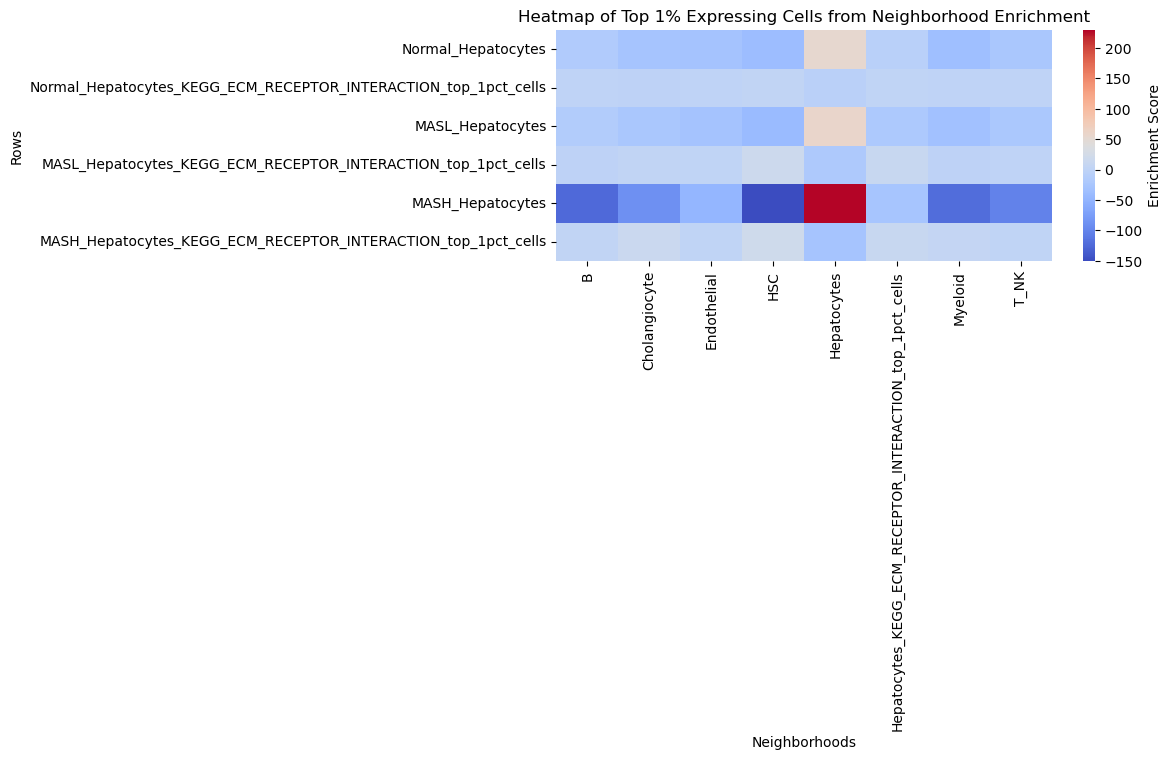

In [8]:
# Plot the rows as a heatmap
plt.figure(figsize=(8, 3))  # Adjust height to fit multiple rows
sns.heatmap(combined, cmap='coolwarm', fmt='.2f', annot=False, 
            cbar_kws={'label': 'Enrichment Score'})

# Add title and labels
plt.title("Heatmap of Top 1% Expressing Cells from Neighborhood Enrichment")
plt.xlabel("Neighborhoods")
plt.ylabel("Rows")
# Show the plot
plt.xticks(rotation=90)
plt.savefig(f"{outp}kegg_neighborhood_analysis_combined.pdf", bbox_inches = "tight")

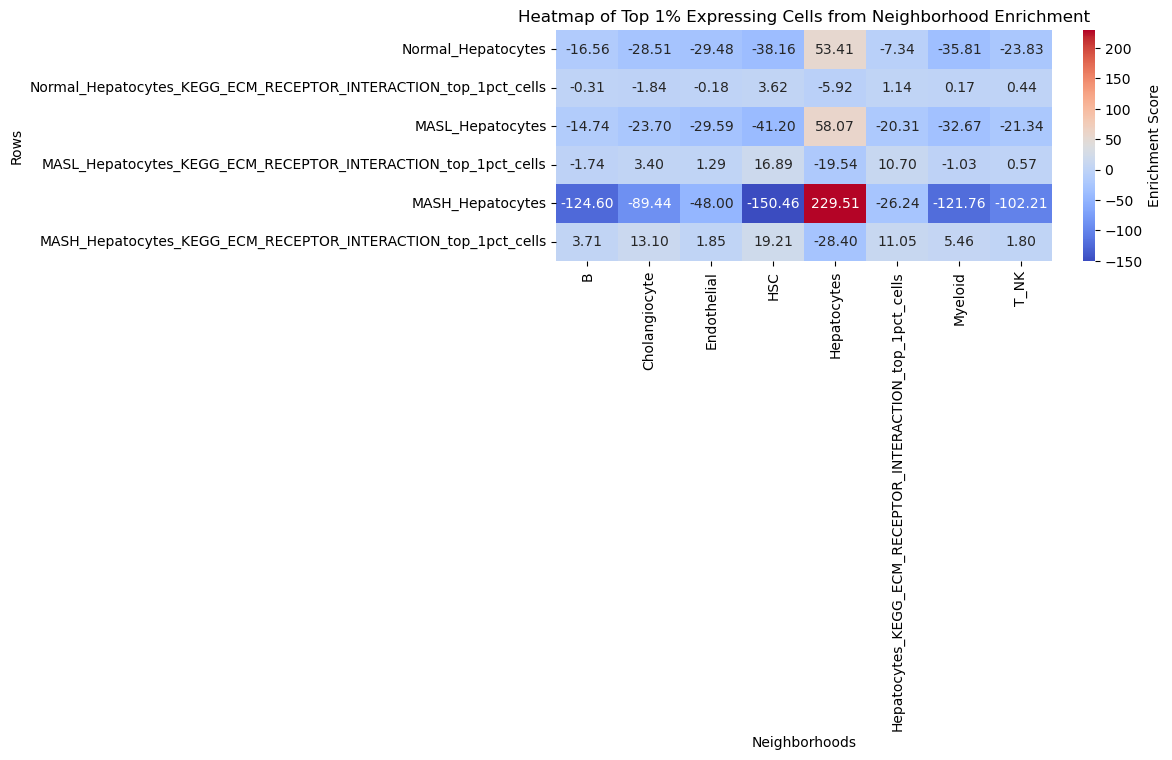

In [9]:
# Plot the rows as a heatmap
plt.figure(figsize=(8, 3))  # Adjust height to fit multiple rows
sns.heatmap(combined, cmap='coolwarm', fmt='.2f', annot=True, 
            cbar_kws={'label': 'Enrichment Score'})

# Add title and labels
plt.title("Heatmap of Top 1% Expressing Cells from Neighborhood Enrichment")
plt.xlabel("Neighborhoods")
plt.ylabel("Rows")
# Show the plot
plt.xticks(rotation=90)
plt.savefig(f"{outp}kegg_neighborhood_analysis_combined_anno.pdf", bbox_inches = "tight")

### Log-transformed version

`sign(x) * log10(|x| + 1e-6)` keeps the sign of the enrichment/depletion while compressing the dynamic range, so both strong positive and negative z-scores remain visible on the same color scale.

In [19]:
combined_log = np.sign(combined) * np.log10(np.abs(combined) + 1e-6)


In [17]:
combined_log

,B,Cholangiocyte,Endothelial,HSC,Hepatocytes,Hepatocytes_KEGG_ECM_RECEPTOR_INTERACTION_top_1pct_cells,Myeloid,T_NK
Normal_Hepatocytes,NaN,NaN,NaN,NaN,1.727653,NaN,NaN,NaN
Normal_Hepatocytes_KEGG_ECM_RECEPTOR_INTERACTION_top_1pct_cells,NaN,NaN,NaN,0.558643,NaN,0.057084,-0.773948,-0.352079
MASL_Hepatocytes,NaN,NaN,NaN,NaN,1.763943,NaN,NaN,NaN
MASL_Hepatocytes_KEGG_ECM_RECEPTOR_INTERACTION_top_1pct_cells,NaN,0.531684,0.111089,1.227625,NaN,1.029360,NaN,-0.241254
MASH_Hepatocytes,NaN,NaN,NaN,NaN,2.360795,NaN,NaN,NaN
MASH_Hepatocytes_KEGG_ECM_RECEPTOR_INTERACTION_top_1pct_cells,0.569509,1.117398,0.267794,1.283563,NaN,1.043291,0.737528,0.255529


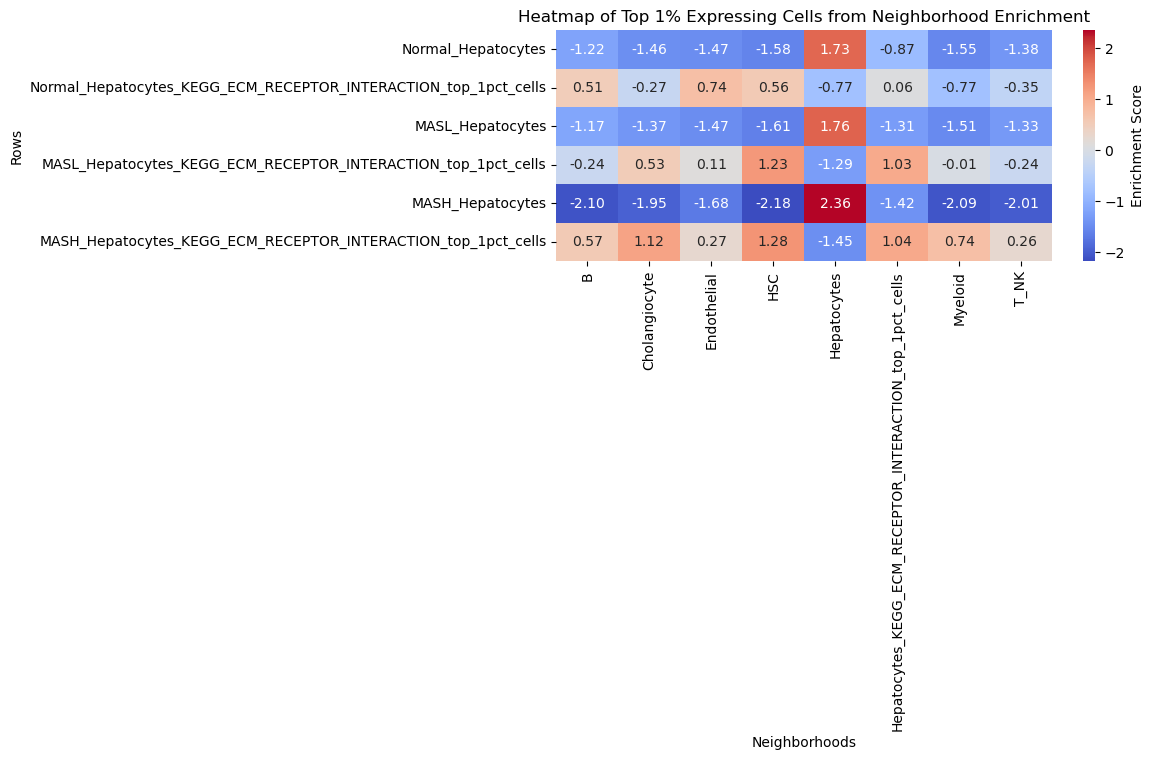

In [21]:
# Plot the rows as a heatmap
plt.figure(figsize=(8, 3))  # Adjust height to fit multiple rows
sns.heatmap(combined_log, cmap='coolwarm', fmt='.2f', annot=True, 
            cbar_kws={'label': 'Enrichment Score'})

# Add title and labels
plt.title("Heatmap of Top 1% Expressing Cells from Neighborhood Enrichment")
plt.xlabel("Neighborhoods")
plt.ylabel("Rows")
# Show the plot
plt.xticks(rotation=90)
plt.savefig(f"{outp}kegg_neighborhood_analysis_combined_log_anno.pdf", bbox_inches = "tight")

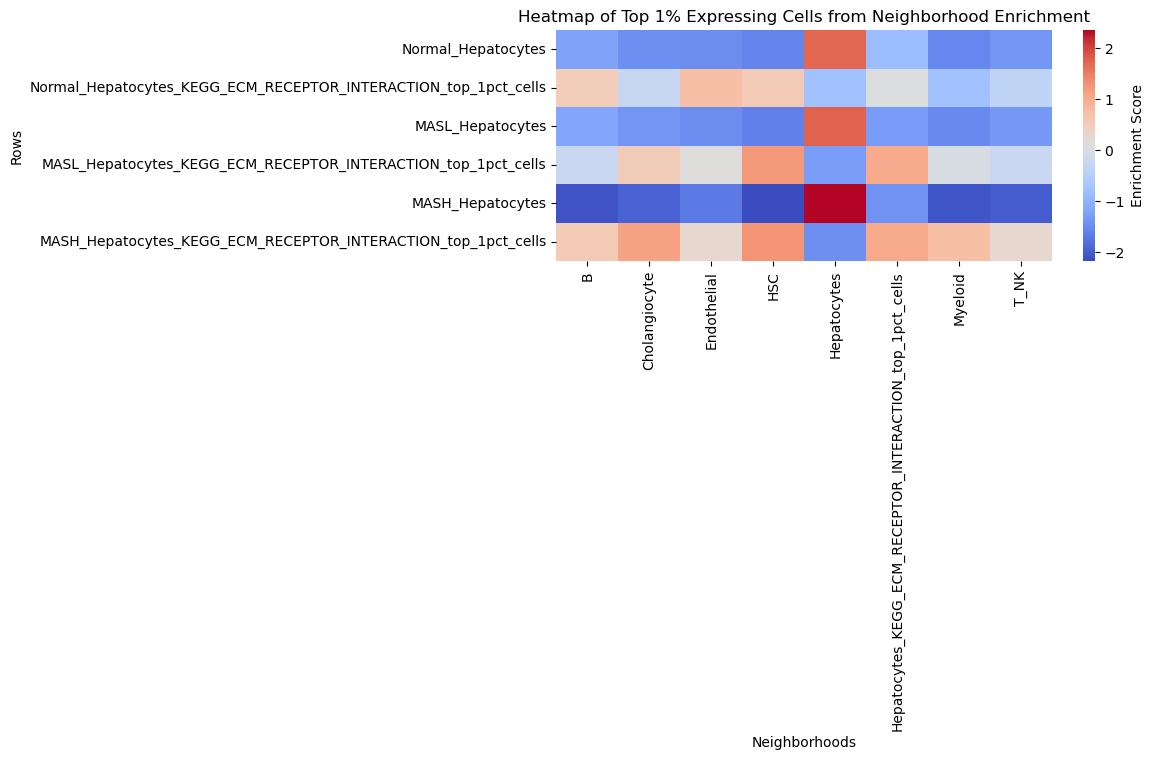

In [22]:
# Plot the rows as a heatmap
plt.figure(figsize=(8, 3))  # Adjust height to fit multiple rows
sns.heatmap(combined_log, cmap='coolwarm', fmt='.2f', annot=False, 
            cbar_kws={'label': 'Enrichment Score'})

# Add title and labels
plt.title("Heatmap of Top 1% Expressing Cells from Neighborhood Enrichment")
plt.xlabel("Neighborhoods")
plt.ylabel("Rows")
# Show the plot
plt.xticks(rotation=90)
plt.savefig(f"{outp}kegg_neighborhood_analysis_combined_log.pdf", bbox_inches = "tight")

## Reactome fatty acids — combined across tissues

In [23]:
outp = '/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/fnih_deg_pathways_module_score_masl/'


In [24]:
base_dir = outp

# Find the per-tissue neighbor-enrichment tables written by the Reactome scoring notebook
csv_files = glob.glob(os.path.join(base_dir, "*", "reactome*.txt"), recursive=True)
print(csv_files)


['/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/fnih_deg_pathways_module_score_masl/HL160029_filt/reactome_fatty_acids_neighbor.txt', '/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/fnih_deg_pathways_module_score_masl/HL230324_filt/reactome_fatty_acids_neighbor.txt', '/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/fnih_deg_pathways_module_score_masl/HL20221019_broad_no_mast_filt/reactome_fatty_acids_neighbor.txt']


In [25]:
dfs = []
for f in csv_files:
    df = pd.read_csv(f, index_col=0, sep="\t")  # keep rownames
    dfs.append(df)

combined = pd.concat(dfs, axis=0)


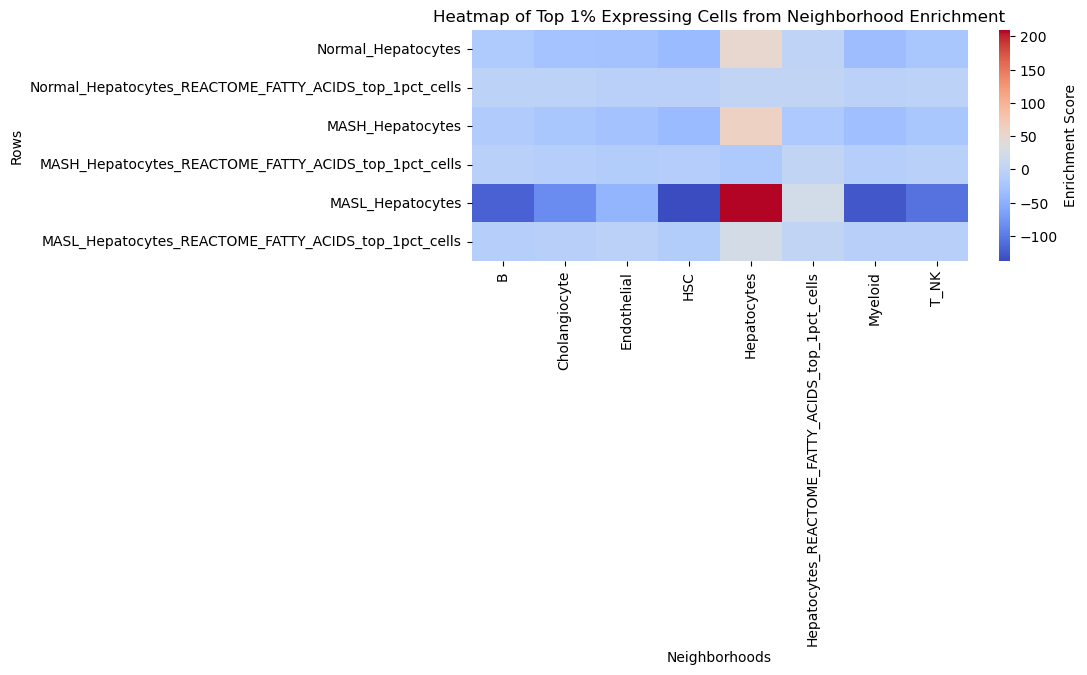

In [13]:
# Plot the rows as a heatmap
plt.figure(figsize=(8, 3))  # Adjust height to fit multiple rows
sns.heatmap(combined, cmap='coolwarm', fmt='.2f', annot=False, 
            cbar_kws={'label': 'Enrichment Score'})

# Add title and labels
plt.title("Heatmap of Top 1% Expressing Cells from Neighborhood Enrichment")
plt.xlabel("Neighborhoods")
plt.ylabel("Rows")
# Show the plot
plt.xticks(rotation=90)
plt.savefig(f"{outp}reactome_neighborhood_analysis_combined.pdf", bbox_inches = "tight")

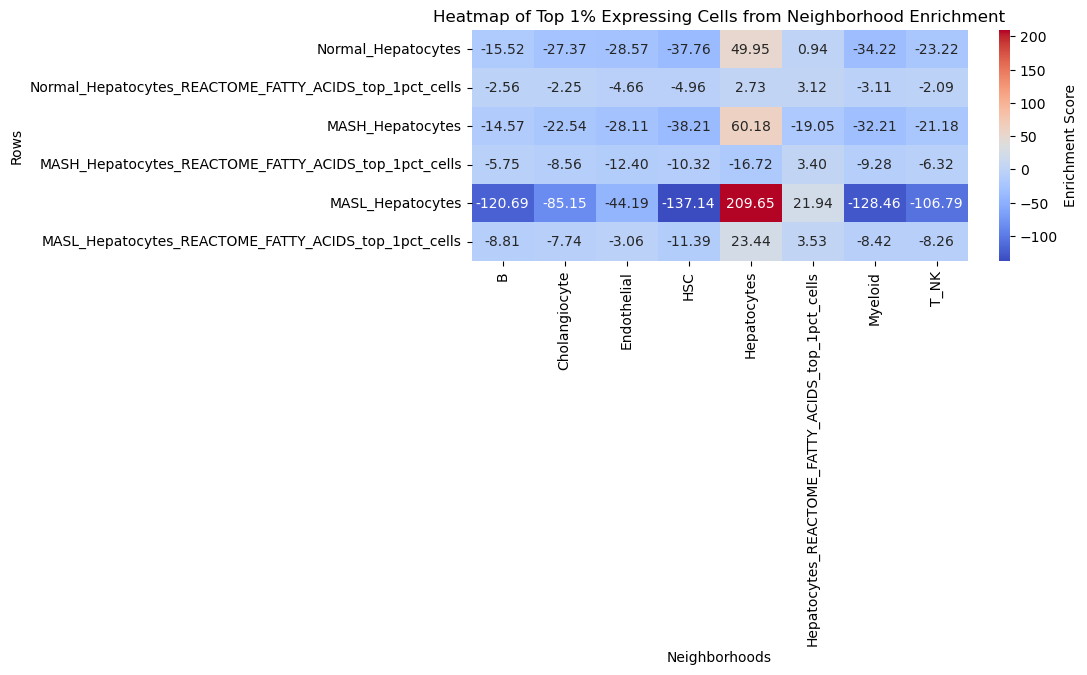

In [14]:
# Plot the rows as a heatmap
plt.figure(figsize=(8, 3))  # Adjust height to fit multiple rows
sns.heatmap(combined, cmap='coolwarm', fmt='.2f', annot=True, 
            cbar_kws={'label': 'Enrichment Score'})

# Add title and labels
plt.title("Heatmap of Top 1% Expressing Cells from Neighborhood Enrichment")
plt.xlabel("Neighborhoods")
plt.ylabel("Rows")
# Show the plot
plt.xticks(rotation=90)
plt.savefig(f"{outp}reactome_neighborhood_analysis_combined_anno.pdf", bbox_inches = "tight")

### Log-transformed version

In [26]:
combined_log = np.sign(combined) * np.log10(np.abs(combined) + 1e-6)


In [27]:
combined_log

,B,Cholangiocyte,Endothelial,HSC,Hepatocytes,Hepatocytes_REACTOME_FATTY_ACIDS_top_1pct_cells,Myeloid,T_NK
Normal_Hepatocytes,-1.191017,-1.437299,-1.455958,-1.576978,1.698517,-0.025592,-1.534286,-1.365918
Normal_Hepatocytes_REACTOME_FATTY_ACIDS_top_1pct_cells,-0.408829,-0.351968,-0.668446,-0.695571,0.436132,0.493925,-0.493318,-0.320679
MASH_Hepatocytes,-1.163437,-1.352881,-1.448909,-1.582186,1.779417,-1.279842,-1.507951,-1.325853
MASH_Hepatocytes_REACTOME_FATTY_ACIDS_top_1pct_cells,-0.759495,-0.932597,-1.093537,-1.013583,-1.223186,0.531211,-0.967543,-0.800859
MASL_Hepatocytes,-2.081688,-1.930198,-1.645336,-2.137151,2.321486,1.341156,-2.108771,-2.028524
MASL_Hepatocytes_REACTOME_FATTY_ACIDS_top_1pct_cells,-0.944747,-0.888943,-0.486313,-1.056587,1.369870,0.547389,-0.925124,-0.916986


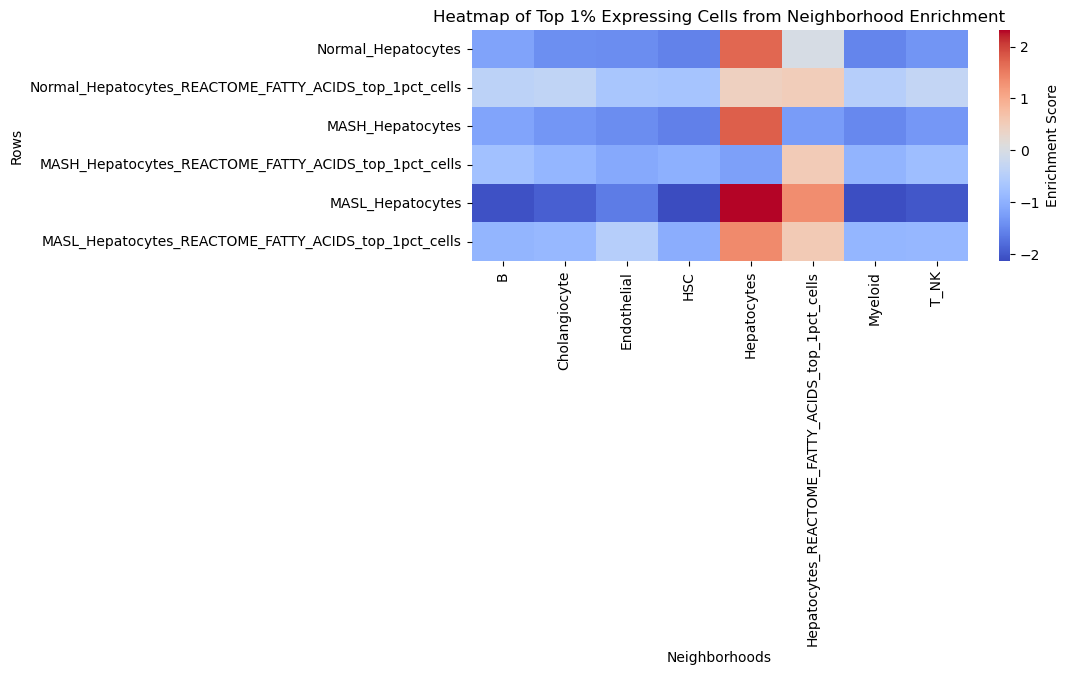

In [28]:
# Plot the rows as a heatmap
plt.figure(figsize=(8, 3))  # Adjust height to fit multiple rows
sns.heatmap(combined_log, cmap='coolwarm', fmt='.2f', annot=False, 
            cbar_kws={'label': 'Enrichment Score'})

# Add title and labels
plt.title("Heatmap of Top 1% Expressing Cells from Neighborhood Enrichment")
plt.xlabel("Neighborhoods")
plt.ylabel("Rows")
# Show the plot
plt.xticks(rotation=90)
plt.savefig(f"{outp}reactome_neighborhood_analysis_combined_log.pdf", bbox_inches = "tight")

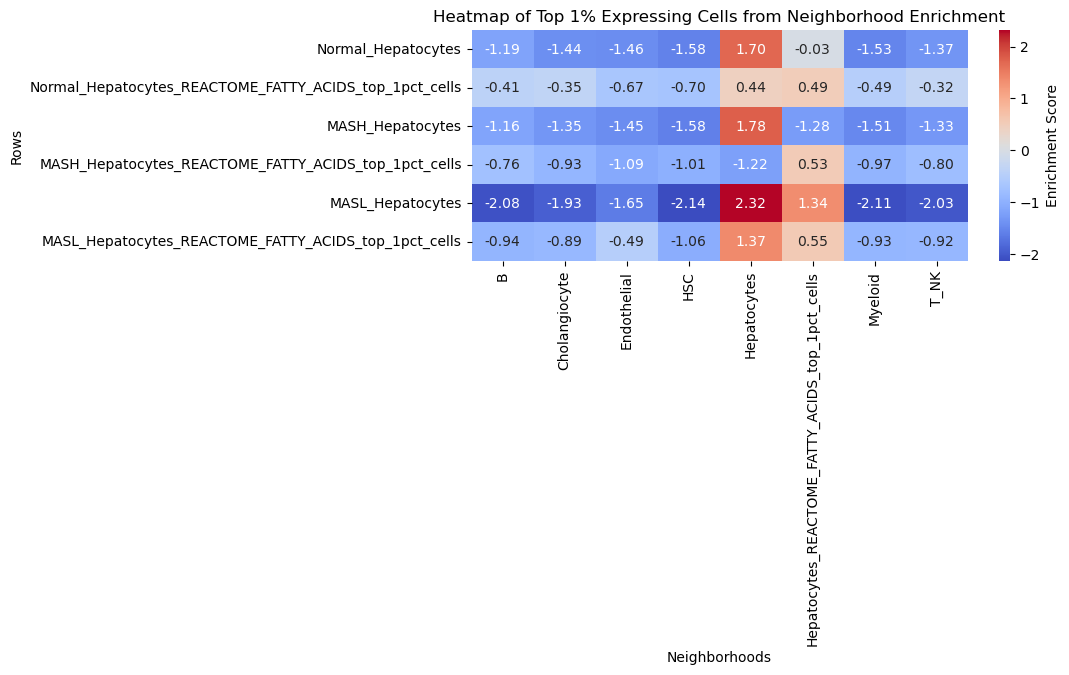

In [29]:
# Plot the rows as a heatmap
plt.figure(figsize=(8, 3))  # Adjust height to fit multiple rows
sns.heatmap(combined_log, cmap='coolwarm', fmt='.2f', annot=True, 
            cbar_kws={'label': 'Enrichment Score'})

# Add title and labels
plt.title("Heatmap of Top 1% Expressing Cells from Neighborhood Enrichment")
plt.xlabel("Neighborhoods")
plt.ylabel("Rows")
# Show the plot
plt.xticks(rotation=90)
plt.savefig(f"{outp}reactome_neighborhood_analysis_combined_log_anno.pdf", bbox_inches = "tight")